# Experiments with our new superpowrs


In [ ]:
#| default_exp tutorials/scale

In [ ]:
import sys
import math
import numpy as np
from fastcore.basics import patch
from HexMagic.database import GeoStorage, ChunkedTerrainGenerator, ChunkRef
from HexMagic.primitives import MapRect, MapCord, MapSize, HexPosition
from HexMagic.core import Terrain, TerraDemo



In [ ]:
from HexMagic.climate import TerrainPatterns, DrainageBasins, Geology, TerraDemo, Terrain, GeoBounds, ClimatePreset, TerrainFactory
from HexMagic.primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from HexMagic.styles import StyleCSS, SVGBuilder
from HexMagic.geology import Plate
from HexMagic.geology import River, Watershed
from HexMagic.database import GeoStorageDebugger, ChunkRef
from HexMagic.primitives import HexPosition

## Going up and down.

In many ways trying to think about the chunking and expanding was its own rabbit hole, or more to the point of alice in wonderland of a series of potions that said Eat Me or Drink me.
We need to debug how all of this going. a few things
1. downsample and upsample work but you need to think about the parameters
2. Sealevel is a StyleCSS and not a float. Sealevel is always at 0, but we might different colors (though not as the red or black seas)
3. It might be a case that a child might have hexes that won't map to the parent. when we create a child we should also have two regions - one invalid hexes in it and two a region in the parent where it was extracted. 
4. some algorithms need to make sure that we don't use invalid hexes.
5. The largest a terrain that works as a view port is about 3,000 hexes. we should have things that scale terrain to approximately those sizes. we probaly could handle 6,000 hexes (viewed) but not 60,000
6. red blog https://www.redblobgames.com/grids/hexagons/#pathfinding talks about about algorithms that go up and down in scale. It make sense for path finding (where you do global paths, before dropping down and doing indivual hexes. We are going to need these kinds of things a great deal for merging and wandering. in particular our watershed algorim is n^2 sp we need to reduce the n to just the itmes.
7. I do have more guides about hexpositions, but one rule of thumb is the more you are in that system the better things should work. the x/y is really only for rendering and not concepts.
8. The other system is just a list of points (the fields inside terrain for instance. my other rule of thumb is that numpy makes things better. If we are doing math calcs we should consider it


In [ ]:
mySize = MapSize(200, 200)
myBounds = MapRect(MapCord(0,0), mySize)
coarse = Terrain(myBounds, radius=25)  # Large hexes

# Add some simple elevation pattern
coarse.elevations[coarse.hexGrid.middle] = 500  # Peak in center
for i in coarse.ring(coarse.hexGrid.middle, 1):
    coarse.elevations[i] = 300
for i in coarse.ring(coarse.hexGrid.middle, 2):
    coarse.elevations[i] = 100

print(f"Coarse terrain: {len(coarse.hexGrid.hexes)} hexes")
print(f"Grid: {coarse.hexGrid.nRows}x{coarse.hexGrid.nCols}")

Coarse terrain: 64 hexes
Grid: 8x8


In [ ]:
# Upsample by 2.5x (coarse radius 25 → fine radius 10)
scale = 2.5
fine = coarse.upsample(scale=scale, method='bilinear')

print(f"\nFine terrain: {len(fine.hexGrid.hexes)} hexes")
print(f"Grid: {fine.hexGrid.nRows}x{fine.hexGrid.nCols}")
print(f"Scale factor: {scale}x")


Fine terrain: 400 hexes
Grid: 20x20
Scale factor: 2.5x




https://en.wikipedia.org/wiki/Image_scaling I am assuming this a a good one to go. I have heard about Lanczos but that might be too much right now


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>read_url(url='https://en.wikipedia.org/wiki/Image_scaling')</summary>

```json
{
  "id": "toolu_01TH4bdf38tF2WSP8faZBBeP",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://en.wikipedia.org/wiki/Image_scaling"
    }
  },
  "result": "'Jump to content\\n\\nMain menu\\n\\nMain menu\\n\\nmove to sidebar hide\\n\\nNavigation \\n\\n  * [Main page](/wiki/Main_Page \"Visit the main page \\\\[z\\\\]\")\\n  * [Contents](/wiki/Wikipedia:Contents \"Guides to browsing Wikipedia\")\\n  * [Current events](/wiki/Portal:Current_events \"Articles related to current events\")\\n  * [Random article](/wiki/Special:Random \"Visit a randomly selected article \\\\[x\\\\]\")\\n  * [About Wikipedia](/wiki/Wikipedia:About \"Learn about Wikipedia and how it works\")\\n  * [Contact us](//en.wikipedia.org/wiki/Wikipedia:Contact_us \"How to contact Wikipedia\")\\n\\n\\n\\nContribute \\n\\n  *<TRUNCATED>"
}
```

</details>

Good reference! For terrain elevation data, here's the practical rundown:

**For your hex terrain use case:**

| Algorithm | Best for | Complexity |
|-----------|----------|------------|
| **Nearest-neighbor** | Fast, preserves discrete values (like biome IDs) | Trivial |
| **Bilinear** | Smooth continuous data (elevations), you already have this | Simple |
| **Bicubic** | Better quality than bilinear, less ringing than Lanczos | Moderate |
| **Box sampling** | Downsampling — averages all source hexes that map to target | Good for your downsample |

Lanczos resampling is an approximation to sinc resampling and yields better results than bicubic, but bicubic interpolation can be regarded as a computationally efficient approximation to Lanczos.

**My recommendation for your terrain system:**

1. **Upsampling**: Bilinear is fine for elevation. Bicubic if you want smoother results (scipy has `RectBivariateSpline` with `kx=3, ky=3`)

2. **Downsampling**: Box sampling ensures all input pixels contribute to the output. The trivial solution to the downscale problem is to consider the target pixel a box on the original image and sample all pixels inside the box. This is ideal for your coarsening — average elevations of child hexes that fall within each parent hex.

3. **Skip Lanczos for now** — it can introduce ringing artifacts (overshoots near sharp elevation changes), which could give you weird negative elevations near coastlines. Bicubic is the sweet spot if bilinear isn't smooth enough.

Since you're working with hex grids rather than rectangular pixels, you'll need to adapt these anyway — your current approach of finding overlapping hexes and interpolating is essentially the right idea.

In [ ]:
# Create a validity map for fine terrain
valid_map = np.zeros(len(fine.hexGrid.hexes), dtype=bool)

for fine_idx in range(len(fine.hexGrid.hexes)):
    fine_center = fine.hexGrid.hexes[fine_idx].center
    
    # Map back to coarse grid row/col
    coarse_row = int((fine_center.y - coarse.hexGrid.offset.y - coarse.hexGrid.radius) / (1.5 * coarse.hexGrid.radius))
    coarse_col_offset = 0.5 if coarse_row % 2 == 1 else 0
    coarse_col = int((fine_center.x - coarse.hexGrid.offset.x - coarse.hexGrid.radius) / (np.sqrt(3) * coarse.hexGrid.radius) - coarse_col_offset)
    
    coarse_idx = coarse.hexGrid.row_col_to_index(coarse_row, coarse_col)
    valid_map[fine_idx] = (0 <= coarse_idx < len(coarse.hexGrid.hexes))

print(f"\nValid fine hexes: {valid_map.sum()} / {len(valid_map)} ({100*valid_map.sum()/len(valid_map):.1f}%)")
print(f"Dead space: {(~valid_map).sum()} hexes")



Valid fine hexes: 400 / 400 (100.0%)
Dead space: 0 hexes


In [ ]:
# Create a validity map for fine terrain
valid_map = np.zeros(len(fine.hexGrid.hexes), dtype=bool)

for fine_idx in range(len(fine.hexGrid.hexes)):
    fine_center = fine.hexGrid.hexes[fine_idx].center
    
    # Map back to coarse grid row/col
    coarse_row = int((fine_center.y - coarse.hexGrid.offset.y - coarse.hexGrid.radius) / (1.5 * coarse.hexGrid.radius))
    coarse_col_offset = 0.5 if coarse_row % 2 == 1 else 0
    coarse_col = int((fine_center.x - coarse.hexGrid.offset.x - coarse.hexGrid.radius) / (np.sqrt(3) * coarse.hexGrid.radius) - coarse_col_offset)
    
    coarse_idx = coarse.hexGrid.row_col_to_index(coarse_row, coarse_col)
    valid_map[fine_idx] = (0 <= coarse_idx < len(coarse.hexGrid.hexes))

print(f"\nValid fine hexes: {valid_map.sum()} / {len(valid_map)} ({100*valid_map.sum()/len(valid_map):.1f}%)")
print(f"Dead space: {(~valid_map).sum()} hexes")



Valid fine hexes: 400 / 400 (100.0%)
Dead space: 0 hexes


### Staying the course (or is this coarse)
So a few observations
1. We have nice scale up and sample down especially if we use bilinear.
2. Things are much easier if we use a grid generated with  Coordinate Transform Pipeline (Coarse ↔ Fine)

The key insight: transforming between grids is a **local → normalize → denormalize → local** pipeline.

**The Pipeline:**

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│  SOURCE GRID    │ ──► │  COMMON SPACE   │ ──► │  DEST GRID      │
│  (local coords) │     │  (map coords)   │     │  (local coords) │
└─────────────────┘     └─────────────────┘     └─────────────────┘
```

**Step by step:**

1. **Unmap from source** — Convert the hex position to map coordinates relative to the source grid's origin
   
2. **Align origins** — Apply any offset needed if the two grids don't share the same origin (e.g., if fine grid is a sub-region of coarse)

3. **Scale** — Multiply/divide by the scale factor (radius ratio) to move between resolution levels

4. **Map to destination** — Convert map coordinates back to hex position in the destination grid's local coordinate system

**In code terms:**
```python
# Fine → Coarse
map_pos = fine_hex.center - fine.origin      # 1. To map-relative coords
map_pos = map_pos + origin_offset            # 2. Align if needed  
map_pos = map_pos                            # 3. Scale is handled by hex lookup
coarse_hex = coarse.hexGrid.find_hex(map_pos) # 4. Back to grid coords
```

**Why centered grids help:** When both grids use `HexGrid.centered()` with the same origin, step 2 disappears — the origins already align, and you only need to worry about the scale factor between radii.

can you rewrite these staying the course points so it is clear. we are trying to transform / scale / trsnsform kind of a pipeline

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

### Coordinate Transform Pipeline (Coarse ↔ Fine)

The key insight: transforming between grids is a **local → normalize → denormalize → local** pipeline.

**The Pipeline:**

```
┌─────────────────┐     ┌─────────────────┐     ┌─────────────────┐
│  SOURCE GRID    │ ──► │  COMMON SPACE   │ ──► │  DEST GRID      │
│  (local coords) │     │  (map coords)   │     │  (local coords) │
└─────────────────┘     └─────────────────┘     └─────────────────┘
```

**Step by step:**

1. **Unmap from source** — Convert the hex position to map coordinates relative to the source grid's origin
   
2. **Align origins** — Apply any offset needed if the two grids don't share the same origin (e.g., if fine grid is a sub-region of coarse)

3. **Scale** — Multiply/divide by the scale factor (radius ratio) to move between resolution levels

4. **Map to destination** — Convert map coordinates back to hex position in the destination grid's local coordinate system

**In code terms:**
```python
# Fine → Coarse
map_pos = fine_hex.center - fine.origin      # 1. To map-relative coords
map_pos = map_pos + origin_offset            # 2. Align if needed  
map_pos = map_pos                            # 3. Scale is handled by hex lookup
coarse_hex = coarse.hexGrid.find_hex(map_pos) # 4. Back to grid coords
```

**Why centered grids help:** When both grids use `HexGrid.centered()` with the same origin, step 2 disappears — the origins already align, and you only need to worry about the scale factor between radii.

I want to build a demo of a large world. I want to show/have terrains for the whole thing at maybe a 40 by 60 scaled down ratio something that is displayable, but isn't too big for a web browser and then some interesting sections where I could different weather or watersheds. at the end of the notebook I would want to delete. Basically I got a new toy and want to show it off. a million hexes seems incredible to me

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**Context note:** Some earlier messages were removed due to size limits (originally 9, now 2), so I'm starting fresh here.

---

A million hexes is totally doable! This sounds like a fun demo. Let me make sure I understand the plan:

1. **Full world:** 1000 × 1000 hexes in the database (terrain type per hex)
2. **Overview display:** Scaled down ~40×60 for browser (sampling or aggregating the full map)
3. **Detail regions:** A few zoomed-in sections showing weather/watersheds
4. **Cleanup:** Drop everything at the end

A few quick questions to help shape the approach:

- **Database:** Are you using DuckDB, SQLite, or something else? (DuckDB is quite fast for this kind of thing)
- **Terrain generation:** Do you have terrain data, or should we generate it procedurally (e.g., Perlin noise for elevation → terrain types)?
- **Display:** matplotlib for the hex grids, or something else?

Let me know and we can start sketching out the schema!

In [ ]:

# Set up the chunked generator
generator = ChunkedTerrainGenerator(
    storage=storage,
    coarse_radius=100,     # Large hexes for overview (~40-60 visible)
    fine_radius=75,        # Detailed hexes for chunks
    chunk_rings=15,        # Rings per chunk
    halo_rings=3
)

# Generate the coarse world overview
bounds = MapRect(MapCord(0, 0), MapSize(4000, 3000))
coarse = generator.generate_coarse(
    bounds,
    num_plates=12,
    ocean_fraction=0.1,
    oceanic_sides=['W', 'N'],  # Oceans on west and North
    name="demo_coarse",
    max_lakes=3
)

print(f"Coarse world: {len(coarse.hexGrid.hexes)} hexes")
# Compute weather on coarse
coarse.compute_distance_from_coast()
coarse.compute_weather()

print(f"Coarse map: {len(coarse.hexGrid.hexes)} hexes")
print(f"  Precip range: {coarse.fields['precipitation'].min():.0f} - {coarse.fields['precipitation'].max():.0f} mm")

# Compute watersheds on coarse
coarse_basins = DrainageBasins(coarse)
print(f"  Coarse watersheds: {len(coarse_basins.sheds)}")
for i, ws in enumerate(coarse_basins.sheds[:5]):
    print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")

# Save coarse watersheds
save_ws = storage.save_watersheds(coarse, coarse_basins.sheds, generator.coarse_world_id)
print(f"  Saved: {save_ws.context}")

if True:
    # Find a good center in the coarse map (e.g., middle of the coarse extent)
    coarse_center_q = (min(qs) + max(qs)) // 2  # ~19
    coarse_center_r = (min(rs) + max(rs)) // 2  # ~0

    # Generate chunk there instead of at origin
    origin_chunk = ChunkRef(HexPosition(coarse_center_q, coarse_center_r, -coarse_center_q - coarse_center_r), generator.chunk_rings)
    #detail = generator.generate_chunk(better_chunk, coarse)
else:
    # Generate a detail chunk with weather
    origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
detail = generator.generate_chunk(origin_chunk, coarse)

generator.compute_chunk_weather(detail)

print(f"\nDetail chunk: {len(detail.hexGrid.hexes)} hexes")
print(f"  Precip range: {detail.fields['precipitation'].min():.0f} - {detail.fields['precipitation'].max():.0f} mm")

# Compute watersheds on detail
detail_basins = DrainageBasins(detail)
print(f"  Detail watersheds: {len(detail_basins.sheds)}")
for i, ws in enumerate(detail_basins.sheds[:5]):
    print(f"    WS {i}: {len(ws.region.hexes)} hexes, ocean={ws.is_ocean}")

# Save detail chunk and its watersheds
chunk_id = generator.save_chunk(detail, origin_chunk)
save_detail_ws = storage.save_watersheds(detail, detail_basins.sheds, chunk_id)
print(f"  Saved: {save_detail_ws.context}")

# Visualize both
print("\n--- Coarse Map ---")
coarse.hexGrid.adjustRadius(8)
coarse.colorMap()
coarse.hexGrid.update()
coarse.builder.adjust("rivers", coarse_basins.draw_watersheds(top_n=5))
#display(coarse.builder.show())

print("\n--- Detail Chunk ---")
detail.hexGrid.adjustRadius(8)
detail.colorLevels = coarse.colorLevels
detail.seaLevel = coarse.seaLevel
detail.colorMap()
detail.hexGrid.update()
detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
#display(detail.builder.show())

# Verify we can load them back
load_coarse_ws = storage.load_watersheds(generator.coarse_world_id, coarse)
load_detail_ws = storage.load_watersheds(chunk_id, detail)

print(f"\n✓ Loaded coarse watersheds: {len(load_coarse_ws.data)}")
print(f"✓ Loaded detail watersheds: {len(load_detail_ws.data)}")
detail.field_sizes()

Done at iter 1: 3 lakes
Coarse world: 1200 hexes
Coarse map: 1200 hexes
  Precip range: 4 - 14318 mm


  Coarse watersheds: 84
    WS 0: 9 hexes, ocean=True
    WS 1: 3 hexes, ocean=True
    WS 2: 2 hexes, ocean=True
    WS 3: 5 hexes, ocean=True
    WS 4: 3 hexes, ocean=True
  Saved: 84 watersheds, 485 hexes assigned



Detail chunk: 2120 hexes
  Precip range: 27 - 11243 mm


  Detail watersheds: 98
    WS 0: 24 hexes, ocean=True
    WS 1: 16 hexes, ocean=False
    WS 2: 36 hexes, ocean=False
    WS 3: 47 hexes, ocean=False
    WS 4: 8 hexes, ocean=True


  Saved: 98 watersheds, 960 hexes assigned

--- Coarse Map ---

--- Detail Chunk ---



✓ Loaded coarse watersheds: 84
✓ Loaded detail watersheds: 98
Elevations 2120
hex 2120


++++++++++++++
distance_to_coast 2120

=== DISTANCE_TO_COAST ===
Range:  0.0 to 7.0
Mean:   1.1
Median: 0.2
StdDev: 1.5
Percentiles: 10%=0.0, 25%=0.0, 75%=1.8, 90%=3.4

Distribution:
      0.0 -     0.9: ████████████████████████████████████████ (1314)
      0.9 -     1.8: ████████ (263)
      1.8 -     2.6: ██████ (208)
      2.6 -     3.5: ████ (134)
      3.5 -     4.4: ███ (99)
      4.4 -     5.2: █ (65)
      5.2 -     6.1:  (26)
      6.1 -     7.0:  (11)


++++++++++++++
precipitation 2120

=== PRECIPITATION ===
Range:  27.2 to 11242.5
Mean:   1853.9
Median: 1614.9
StdDev: 1526.8
Percentiles: 10%=166.1, 25%=663.0, 75%=2604.0, 90%=3751.7

Distribution:
     27.2 -  1429.1: ████████████████████████████████████████ (909)
   1429.1 -  2831.1: █████████████████████████████████ (750)
   2831.1 -  4233.0: █████████████ (315)
   4233.0 -  5634.9: ███ (87)
   5634.9 -  7036.8: █ (38)
   7036.8 -  84

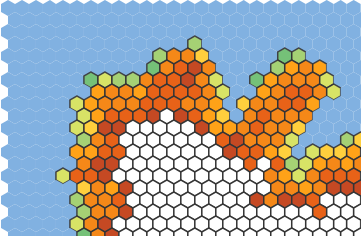

In [ ]:
displayable = detail.shrinkWeather(0.5)
len(displayable.hexGrid.hexes)
displayable.colorMap()
displayable.hexGrid.update()
displayable.hexGrid.builder.show()

In [ ]:
def inherit_watersheds(generator, coarse, detail, chunk, coarse_watersheds):
    """Assign detail hexes to coarse watersheds by parent mapping."""
    scale = generator.scale
    detail_grid = detail.hexGrid
    coarse_grid = coarse.hexGrid
    
    # Build coarse_idx -> watershed_id lookup
    coarse_to_ws = {}
    for ws_id, ws in enumerate(coarse_watersheds):
        for hex_idx in ws.region.hexes:
            coarse_to_ws[hex_idx] = ws_id
    
    # Map each detail hex
    detail_watershed = np.full(len(detail.elevations), -1, dtype=int)
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        
        if coarse_idx in coarse_to_ws:
            detail_watershed[detail_idx] = coarse_to_ws[coarse_idx]
    
    return detail_watershed


In [ ]:
inherit_watersheds(generator,coarse,detail,origin_chunk,coarse_basins.sheds)

array([-1, -1, -1, ..., -1, -1, -1], shape=(3249,))

In [ ]:
from HexMagic.styles import StyleCSS

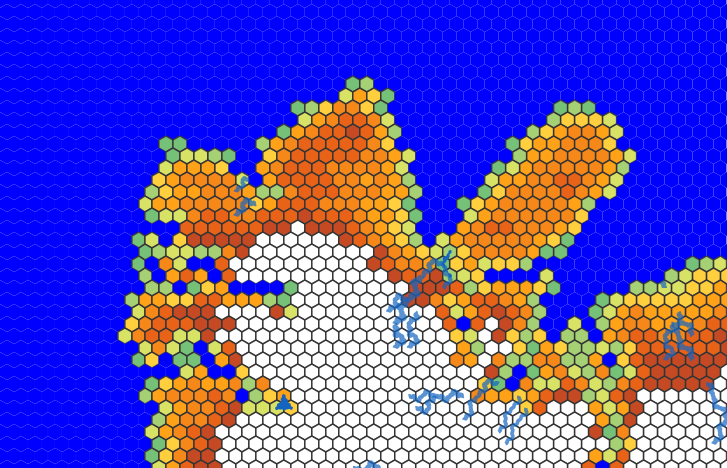

In [ ]:
detail.hexGrid.adjustRadius(8)
detail.colorLevels = coarse.colorLevels
detail.seaLevel = coarse.seaLevel
detail.hexGrid.builder.layers = []
sea = StyleCSS("sealevel",fill="blue")
  
detail.hexGrid.builder.add_style(sea)
detail.colorMap()
detail.hexGrid.update()
detail.builder.adjust("rivers", detail_basins.draw_watersheds(top_n=5))
detail.builder.show()

In [ ]:
cat ../../HexMagic/water/*.py

# AUTOGENERATED! DO NOT EDIT! File to edit: ../../nbs/water/basin.ipynb.

# %% auto #0
__all__ = ['DrainageBasins']

# %% ../../nbs/water/basin.ipynb #dbb6cb4a
import numpy as np
import sys
import os
import math
import random

#data
from collections import namedtuple
from dataclasses import dataclass,  field, asdict
from typing import List
from enum import Enum
import heapq

#Jeremy
from dialoghelper import * 
from fastcore.basics import patch
from fasthtml.common import *
from fasthtml.jupyter import *
import httpx

#custom
import copy

# %% ../../nbs/water/basin.ipynb #f400829f
from ..styles import StyleCSS, SVGBuilder, SVGLayer, SVGPatternLoader, preview, app, StyleDemo, LayerAnimation
from ..primitives import MapCord, MapSize, MapRect, MapPath, Hex, HexGrid, HexWrapper, HexPosition, hexBackground, HexRegion, unique_windy_edge
from ..terrain import  TerraDemo, Terrain, GeoBounds, ClimatePreset
from ..terrainpatterns import TerrainPatterns, SVGMask

# %% ../../nbs/water/basin.ipynb #

can you build a demo inherit_watersheds and our terrains with an overlay showing them

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

Anthropic API is currently down. Please try again later. See [status.claude.com](https://status.claude.com/) for official updates.

In [ ]:
detail.builder.show()

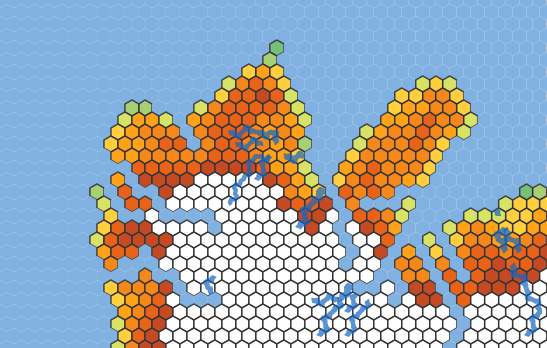

In [ ]:
coarse.hexGrid.builder.show()

In [ ]:
# Demo inherit_watersheds with our existing terrains
detail_ws_ids = inherit_watersheds(generator, coarse, detail, origin_chunk, coarse_basins.sheds)

# See distribution
unique, counts = np.unique(detail_ws_ids, return_counts=True)
print(f"Detail hexes: {len(detail_ws_ids)}")
print(f"Assigned to {len(unique[unique >= 0])} coarse watersheds")
print(f"Unassigned: {counts[unique == -1].sum() if -1 in unique else 0}")

# Show top watersheds by hex count
for ws_id, count in sorted(zip(unique, counts), key=lambda x: -x[1])[:8]:
    if ws_id >= 0:
        print(f"  WS {ws_id}: {count} detail hexes")

# Visualize by coloring detail hexes by parent watershed
detail.fields['parent_watershed'] = detail_ws_ids.astype(float)

# Quick color map using watershed ID
from matplotlib import cm
cmap = cm.get_cmap('tab20', len(coarse_basins.sheds))

for idx, ws_id in enumerate(detail_ws_ids):
    if ws_id >= 0:
        rgba = cmap(ws_id % 20)
        detail.hexGrid.hexes[idx].fill = f"rgb({int(rgba[0]*255)},{int(rgba[1]*255)},{int(rgba[2]*255)})"
    else:
        detail.hexGrid.hexes[idx].fill = "#444444"  # Unassigned = dark gray

detail.hexGrid.update()

Detail hexes: 3249
Assigned to 42 coarse watersheds
Unassigned: 2882
  WS 34: 47 detail hexes
  WS 32: 33 detail hexes
  WS 23: 27 detail hexes
  WS 10: 18 detail hexes
  WS 27: 17 detail hexes
  WS 57: 17 detail hexes
  WS 8: 14 detail hexes


/tmp/ipykernel_5042/46926886.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', len(coarse_basins.sheds))


In [ ]:
coarse.field_sizes()

In [ ]:
detail.field_sizes()

Elevations 3249
hex 3249


++++++++++++++
distance_to_coast 3249

=== DISTANCE_TO_COAST ===
Range:  0.0 to 5.0
Mean:   0.5
Median: 0.0
StdDev: 0.7
Percentiles: 10%=0.0, 25%=0.0, 75%=1.0, 90%=1.0

Distribution:
      0.0 -     0.6: ████████████████████████████████████████ (1937)
      0.6 -     1.2: ████████████████████████ (1170)
      1.2 -     1.9:  (0)
      1.9 -     2.5: █ (82)
      2.5 -     3.1:  (40)
      3.1 -     3.8:  (0)
      3.8 -     4.4:  (15)
      4.4 -     5.0:  (5)


++++++++++++++
precipitation 3249

=== PRECIPITATION ===
Range:  11.6 to 5868.2
Mean:   1387.6
Median: 1307.2
StdDev: 706.0
Percentiles: 10%=777.7, 25%=1063.8, 75%=1543.7, 90%=2159.8

Distribution:
     11.6 -   743.7: █████ (301)
    743.7 -  1475.7: ████████████████████████████████████████ (2039)
   1475.7 -  2207.8: ████████████ (614)
   2207.8 -  2939.9: ███ (169)
   2939.9 -  3672.0: █ (74)
   3672.0 -  4404.0:  (32)
   4404.0 -  5136.1:  (16)
   5136.1 -  5868.2:  (4)


++++++++++++++
precip_rat

In [ ]:
??Terrain


```python
class Terrain:

    def __init__(self,
    bounds:MapRect, #our canvas size, 
    path: str = "sample.svg", #where are we going to export
    radius: float = 25.0, #default hex size,
    fields:[str] = [],
    colorLevels:[StyleCSS] = StyleCSS.elevations(),
    seaLevel:StyleCSS =  StyleCSS("sealevel",fill ="#81b1e1ff"),
    elevationDelta:float = 90,
    geo:GeoBounds = None,
    climate:ClimatePreset = None


    ):
        self.colorLevels = colorLevels
        self.seaLevel = seaLevel
        self.hexGrid = HexGrid.from_bounds(bounds, radius=radius, style=seaLevel)
        self.hexGrid.builder.add_style(seaLevel)
        self.path = path
        self.climate = climate

        for  x in self.colorLevels: 
            hover = StyleCSS("hover",fill=x.desaturate().properties["fill"],cursor="pointer" )
            #hover = StyleCSS("hover",fill="#007fff",cursor="pointer" )
            x.customize(hover)
            self.hexGrid.builder.add_style(x)

        self.elevationDelta = elevationDelta
        self.elevations = np.zeros(len(self.hexGrid.hexes))
        self.fields = {}
        self.geo = geo
        for field in  fields:
            self.fields[field] = np.zeros(len(self.hexGrid.hexes))

    @property
    def builder(self):
        return self.hexGrid.builder

    def colorMap(self):
        numHeights = len(self.colorLevels)
        if numHeights < 1:
            return 0
        for i in range(len(self.elevations)):
            height = int(self.elevations[i]  / self.elevationDelta)

            aLevel =  self.seaLevel
            if self.elevations[i]  > 0:
                if height < numHeights:
                    aLevel = self.colorLevels[height]
                else:
                    aLevel = self.colorLevels[-1]
            self.hexGrid.hexes[i].style = aLevel



    def textElevations(self):
        grid = self.hexGrid 
        nRows = grid.nRows
        nCols =  grid.nCols

        i = 0
        for row in range(nRows):

            line = "|"
            for col in range(nCols):
                line += f" { int(self.elevations[i]/100):3}"
                i += 1

            print(line + " |")

    def textStyle(self):
        grid = self.hexGrid 
        nRows = grid.nRows
        nCols =  grid.nCols

        i = 0
        for row in range(nRows):

            line = "|"
            for col in range(nCols):
                line += f" { self.hexGrid.hexes[i].style.name[:3]:3}"
                i += 1

            print(line + " |")


    def encode(self):
        grid = self.hexGrid 
        nRows = grid.nRows
        nCols = grid.nCols
        ret = f"radius:{self.hexGrid.radius}\n"
        ret += f"size:{self.hexGrid.nRows}^{self.hexGrid.nCols}\n"
        ret += f"path:{self.path}\n"
        field_names = '\t'.join(self.fields.keys())
        ret += f"fields:{field_names}\n"


        # Add geobounds if present
        if self.geo is not None:
            ret += f"geo:{self.geo.lat_min},{self.geo.lat_max},{self.geo.lon_min},{self.geo.lon_max}\n"

        # Add climate if present
        if self.climate is not None:
            ret += f"climate:{self.climate.encode()}\n"

        ret += f"+data:\n"
        i = 0
        for row in range(nRows):
            line = []
            for col in range(nCols):
                csv_parts = [str(self.elevations[i])]
                for fieldName in self.fields.keys():
                    csv_parts.append(str(self.fields[fieldName][i]))
                line.append(','.join(csv_parts))
                i += 1
            ret += "\t".join(line) + "\n"
        ret += f"-data:\n"

        return ret


    @staticmethod
    def decode(s: str):
        """Parse a formatted string and create a Terrain from it."""
        lines = s.strip().split('\n')

        # Parse header
        radius = None
        path = None
        geo = None
        climate = None  # New: store climate preset
        inGrid = False
        nRow = 0
        nCol = 0
        fieldNames = []
        elevations = []
        fieldData = {}

        for line in lines:
            if not inGrid:
                if ':' not in line:
                    continue
                val = line.split(':', 1)[1].strip()  # Use maxsplit=1 for climate line

                if line.startswith('radius:'):
                    radius = float(val)
                elif line.startswith('size:'):
                    size = val.split('^')
                    nRow = int(size[0])
                    nCol = int(size[1])
                elif line.startswith('path:'):
                    path = val
                elif line.startswith('fields:'):
                    fieldNames = val.split('\t')
                elif line.startswith('geo:'):
                    coords = val.split(',')
                    geo = GeoBounds(
                        lat_min=float(coords[0]),
                        lat_max=float(coords[1]),
                        lon_min=float(coords[2]),
                        lon_max=float(coords[3])
                    )
                elif line.startswith('climate:'):
                    climate = ClimatePreset.decode(val)
                elif line.startswith('+data:'):
                    inGrid = True
                    fieldData = {name: [] for name in fieldNames}
            else:
                if line.startswith('-data:'):
                    break
                else:
                    cells = line.split('\t')
                    for cell in cells:
                        values = cell.split(',')
                        elevations.append(float(values[0]))
                        for i, fieldName in enumerate(fieldNames):
                            fieldData[fieldName].append(float(values[i + 1]))

        # Create Terrain object
        bounds = MapRect(MapCord(0, 0), MapSize(nRow * radius, nCol * radius))
        retTerrain = Terrain(bounds=bounds, path=path, radius=radius, climate=climate, geo=geo)
        retTerrain.hexGrid.nRows = nRow
        retTerrain.hexGrid.nCols = nCol
        retTerrain.hexGrid.adjustRadius(radius)

        retTerrain.elevations = np.array(elevations)
        retTerrain.fields = {name: np.array(fieldData[name]) for name in fieldNames}

        return retTerrain
```

**File:** `~/HexMagic/HexMagic/terrain.py`

So the detail has too much water in it. the coarse map is much higher. a few things
1. seavlevel is a coloring style not an elevation. Sea Level is always 0 elevation but there might be different color oceans (though I don't do the red sea)
2. maybe we can have an overlay on the master map that shows where the detail is coming from. 
3. if we have a function between the two terrains we can see how elevation is being transformed

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good observations! Let's tackle these one at a time:

**1. Sea level / water issue:** So if the detail chunk has "too much water," that means the upsampling is producing elevations ≤ 0 where the coarse map had land. This could be:
- The bilinear interpolation averaging land with nearby ocean hexes
- The detail noise (`_add_detail`) pushing elevations below zero
- A coordinate mapping issue (wrong region being extracted)

**2. Overlay:** Great idea — we could mark the coarse hexes that correspond to the detail chunk's coverage area, maybe with a border or different fill.

**3. Elevation comparison:** We could sample a few corresponding points and print `(coarse_elev, detail_elev)` pairs to see what's happening.

---

Which would you like to dig into first? I'd suggest starting with **#3** since that'll tell us if the elevation data is being transformed incorrectly — that would explain the water problem.

Want me to sketch out a quick comparison, or would you prefer to write something yourself?

lets do 3. can you write something that will check a detail hex in its parrent coarse one

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
def compare_elevations(generator, coarse, detail, chunk, num_samples=10):
    """Compare elevations between detail hexes and their parent coarse hexes."""
    
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    print(f"Scale factor: {scale}")
    print(f"Coarse hexes: {len(coarse.elevations)}, Detail hexes: {len(detail.elevations)}")
    print(f"\n{'Detail idx':>10} {'Detail pos':>15} {'Detail elev':>12} {'Coarse pos':>15} {'Coarse elev':>12} {'Ratio':>8}")
    print("-" * 80)
    
    # Sample some detail hexes
    sample_indices = np.linspace(0, len(detail.elevations)-1, num_samples, dtype=int)
    
    for detail_idx in sample_indices:
        # Get detail position (local to chunk)
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        detail_elev = detail.elevations[detail_idx]
        
        # Map to world position, then to coarse
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        
        # Find coarse hex
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        if 0 <= coarse_idx < len(coarse.elevations):
            coarse_elev = coarse.elevations[coarse_idx]
            ratio = detail_elev / coarse_elev if coarse_elev != 0 else float('inf')
            print(f"{detail_idx:>10} {str(detail_pos):>15} {detail_elev:>12.1f} {str(coarse_pos):>15} {coarse_elev:>12.1f} {ratio:>8.2f}")
        else:
            print(f"{detail_idx:>10} {str(detail_pos):>15} {detail_elev:>12.1f} {str(coarse_pos):>15} {'OUT OF BOUNDS':>12}")

# Run it
compare_elevations(generator, coarse, detail, origin_chunk, num_samples=15)
```

This will show you side-by-side: the detail hex position, its elevation, the corresponding coarse hex, and a ratio. If the ratio is wildly different from 1.0 (or if coarse is positive but detail is ≤0), we'll see where the problem is.

In [ ]:
def compare_elevations(generator, coarse, detail, chunk, num_samples=10):
    """Compare elevations between detail hexes and their parent coarse hexes."""
    
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    print(f"Scale factor: {scale}")
    print(f"Coarse hexes: {len(coarse.elevations)}, Detail hexes: {len(detail.elevations)}")
    print(f"\n{'Detail idx':>10} {'Detail pos':>15} {'Detail elev':>12} {'Coarse pos':>15} {'Coarse elev':>12} {'Ratio':>8}")
    print("-" * 80)
    
    # Sample some detail hexes
    sample_indices = np.linspace(0, len(detail.elevations)-1, num_samples, dtype=int)
    
    for detail_idx in sample_indices:
        # Get detail position (local to chunk)
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        detail_elev = detail.elevations[detail_idx]
        
        # Map to world position, then to coarse
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_s = -coarse_q - coarse_r
        coarse_pos = HexPosition(coarse_q, coarse_r, coarse_s)
        
        # Find coarse hex
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        if 0 <= coarse_idx < len(coarse.elevations):
            coarse_elev = coarse.elevations[coarse_idx]
            ratio = detail_elev / coarse_elev if coarse_elev != 0 else float('inf')
            print(f"{detail_idx:>10} {str(detail_pos):>15} {detail_elev:>12.1f} {str(coarse_pos):>15} {coarse_elev:>12.1f} {ratio:>8.2f}")
        else:
            print(f"{detail_idx:>10} {str(detail_pos):>15} {detail_elev:>12.1f} {str(coarse_pos):>15} {'OUT OF BOUNDS':>12}")

# Run it
compare_elevations(generator, coarse, detail, origin_chunk, num_samples=15)


Scale factor: 1.3333333333333333
Coarse hexes: 1200, Detail hexes: 3249

Detail idx      Detail pos  Detail elev      Coarse pos  Coarse elev    Ratio
--------------------------------------------------------------------------------
         0 HexPosition(-14, -28, 42)          3.2 HexPosition(-10, -21, 31) OUT OF BOUNDS
       232 HexPosition(-12, -24, 36)         -3.2 HexPosition(-9, -18, 27) OUT OF BOUNDS
       464 HexPosition(-10, -20, 30)          8.0 HexPosition(-7, -15, 22) OUT OF BOUNDS
       696 HexPosition(-8, -16, 24)          4.9 HexPosition(-6, -12, 18) OUT OF BOUNDS
       928 HexPosition(-6, -12, 18)          8.8 HexPosition(-4, -9, 13) OUT OF BOUNDS
      1160 HexPosition(-4, -8, 12)         -3.4 HexPosition(-3, -6, 9) OUT OF BOUNDS
      1392 HexPosition(-2, -4, 6)          0.7 HexPosition(-1, -3, 4) OUT OF BOUNDS
      1624 HexPosition(0, 0, 0)       -358.1 HexPosition(0, 0, 0)       -419.2     0.85
      1856 HexPosition(2, 4, -6)       -378.6 HexPosition(1, 3, -4) 

So I probaly want to have something that skips or marks different for those hexes that don't correspond up to a parent. We should not return a detail terrain for a hex that doesn't have a parent.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right! The detail chunk is extending beyond the coarse map's coverage. Let's write a function to identify valid hexes and one to mask/trim the detail:

```python
def get_valid_detail_mask(generator, coarse, detail, chunk):
    """Return boolean mask: True for detail hexes with valid coarse parents."""
    
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    valid = np.zeros(len(detail.elevations), dtype=bool)
    
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        world_pos = chunk.center_hex + detail_pos
        
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        if 0 <= coarse_idx < len(coarse.elevations):
            valid[detail_idx] = True
    
    return valid

# Check it
valid_mask = get_valid_detail_mask(generator, coarse, detail, origin_chunk)
print(f"Valid detail hexes: {valid_mask.sum()} / {len(valid_mask)} ({100*valid_mask.mean():.1f}%)")
print(f"Invalid (no parent): {(~valid_mask).sum()}")
```

Now you have options:

**Option A:** Just visualize the invalid ones differently:
```python
# Mark invalid hexes as gray
for idx, is_valid in enumerate(valid_mask):
    if not is_valid:
        detail.hexGrid.hexes[idx].fill = "#333333"
detail.hexGrid.update()
```

**Option B:** Trim the detail terrain to only valid hexes (more complex, needs `HexRegion.crop_to_centered_grid`)

**Option C:** Fix upstream — ensure `generate_chunk` only creates hexes within coarse coverage. This would go in `ChunkedTerrainGenerator.generate_chunk`:

```python
# After upsampling, mask out hexes without valid parents
valid_mask = get_valid_detail_mask(self, coarse, fine_terrain, chunk)
fine_terrain.elevations[~valid_mask] = 0  # Or some sentinel value
```

Which approach would you like to pursue?

In [ ]:
def get_valid_detail_mask(generator, coarse, detail, chunk):
    """Return boolean mask: True for detail hexes with valid coarse parents."""
    
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    valid = np.zeros(len(detail.elevations), dtype=bool)
    
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        world_pos = chunk.center_hex + detail_pos
        
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        if 0 <= coarse_idx < len(coarse.elevations):
            valid[detail_idx] = True
    
    return valid

# Check it
valid_mask = get_valid_detail_mask(generator, coarse, detail, origin_chunk)
print(f"Valid detail hexes: {valid_mask.sum()} / {len(valid_mask)} ({100*valid_mask.mean():.1f}%)")
print(f"Invalid (no parent): {(~valid_mask).sum()}")


Valid detail hexes: 1222 / 3249 (37.6%)
Invalid (no parent): 2027


That is quite a lot

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yeah, that's a problem. The scale is only 1.33× (100/75), so the detail chunk isn't much finer than coarse — but it's generating way more hexes than the coarse map can cover.

Let's see what's going on:

```python
# Check the extents
print("=== Coarse map extent ===")
print(f"Total hexes: {len(coarse.elevations)}")
print(f"Grid: {coarse.hexGrid.nRows} x {coarse.hexGrid.nCols}")

# Sample coarse positions to see range
coarse_positions = [coarse.hexGrid.index_to_hexposition(i) for i in range(len(coarse.elevations))]
qs = [p.q for p in coarse_positions]
rs = [p.r for p in coarse_positions]
print(f"Q range: {min(qs)} to {max(qs)}")
print(f"R range: {min(rs)} to {max(rs)}")

print("\n=== Detail chunk extent ===")
print(f"Total hexes: {len(detail.elevations)}")
print(f"Chunk rings: {generator.chunk_rings}, Halo: {generator.halo_rings}")
print(f"Scale: {generator.scale}")

# What range does detail need in coarse coords?
detail_positions = [detail.hexGrid.index_to_hexposition(i, origin_index=detail.hexGrid.middle) 
                    for i in range(len(detail.elevations))]
# Map to coarse coords
coarse_needed_qs = [int(p.q / generator.scale) for p in detail_positions]
coarse_needed_rs = [int(p.r / generator.scale) for p in detail_positions]
print(f"Needs coarse Q: {min(coarse_needed_qs)} to {max(coarse_needed_qs)}")
print(f"Needs coarse R: {min(coarse_needed_rs)} to {max(coarse_needed_rs)}")
```

I suspect either:
- The scale is too small (1.33 isn't much zoom)
- The chunk_rings (15) is too large relative to the coarse map
- The coarse map doesn't use a centered grid with `middle` set properly

What ratio were you aiming for between coarse and detail?

In [ ]:
# Check the extents
print("=== Coarse map extent ===")
print(f"Total hexes: {len(coarse.elevations)}")
print(f"Grid: {coarse.hexGrid.nRows} x {coarse.hexGrid.nCols}")

# Sample coarse positions to see range
coarse_positions = [coarse.hexGrid.index_to_hexposition(i) for i in range(len(coarse.elevations))]
qs = [p.q for p in coarse_positions]
rs = [p.r for p in coarse_positions]
print(f"Q range: {min(qs)} to {max(qs)}")
print(f"R range: {min(rs)} to {max(rs)}")

print("\n=== Detail chunk extent ===")
print(f"Total hexes: {len(detail.elevations)}")
print(f"Chunk rings: {generator.chunk_rings}, Halo: {generator.halo_rings}")
print(f"Scale: {generator.scale}")

# What range does detail need in coarse coords?
detail_positions = [detail.hexGrid.index_to_hexposition(i, origin_index=detail.hexGrid.middle) 
                    for i in range(len(detail.elevations))]
# Map to coarse coords
coarse_needed_qs = [int(p.q / generator.scale) for p in detail_positions]
coarse_needed_rs = [int(p.r / generator.scale) for p in detail_positions]
print(f"Needs coarse Q: {min(coarse_needed_qs)} to {max(coarse_needed_qs)}")
print(f"Needs coarse R: {min(coarse_needed_rs)} to {max(coarse_needed_rs)}")


=== Coarse map extent ===
Total hexes: 1200
Grid: 30 x 40
Q range: -7 to 46
R range: -15 to 14

=== Detail chunk extent ===
Total hexes: 3249
Chunk rings: 15, Halo: 3
Scale: 1.3333333333333333
Needs coarse Q: -31 to 31
Needs coarse R: -21 to 21


Thoughts?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The problem is a mismatch in centering:

- **Coarse map:** Q from -7 to 46 (offset positive, not centered at origin)
- **Detail chunk:** Centered at (0,0,0), needs Q from -31 to 31

The chunk is centered at the origin, but the coarse map doesn't extend into negative Q territory much. Half the detail chunk is "off the map."

**Two fixes:**

**A) Pick a chunk center that's actually in the coarse map:**
```python
# Find a good center in the coarse map (e.g., middle of the coarse extent)
coarse_center_q = (min(qs) + max(qs)) // 2  # ~19
coarse_center_r = (min(rs) + max(rs)) // 2  # ~0

# Generate chunk there instead of at origin
better_chunk = ChunkRef(HexPosition(coarse_center_q, coarse_center_r, -coarse_center_q - coarse_center_r), generator.chunk_rings)
detail2 = generator.generate_chunk(better_chunk, coarse)
```

**B) Generate the coarse map centered at origin:**
Use `HexGrid.centered()` instead of `HexGrid.from_bounds()` in `generate_coarse`.

---

I'd go with **A** for now since you already have the coarse map. Want to try generating a chunk at a center that's actually covered?

In [ ]:
# Find land hexes in coarse map
land_indices = np.where(coarse.elevations > 0)[0]
print(f"Land hexes: {len(land_indices)} / {len(coarse.elevations)}")

# Get positions of some land hexes
print("\nSample land positions in coarse:")
for idx in land_indices[:10]:
    pos = coarse.hexGrid.index_to_hexposition(idx)
    print(f"  idx {idx}: {pos}, elev={coarse.elevations[idx]:.0f}")

# What's the center-most land hex?
land_distances = []
for idx in land_indices:
    pos = coarse.hexGrid.index_to_hexposition(idx)
    dist = abs(pos)  # hex distance from origin
    land_distances.append((dist, idx, pos))
land_distances.sort()
print(f"\nClosest land to origin: {land_distances[0]}")


Land hexes: 286 / 1200

Sample land positions in coarse:
  idx 496: HexPosition(17, -3, -14), elev=118
  idx 535: HexPosition(16, -2, -14), elev=250
  idx 536: HexPosition(17, -2, -15), elev=171
  idx 574: HexPosition(14, -1, -13), elev=121
  idx 575: HexPosition(15, -1, -14), elev=252
  idx 576: HexPosition(16, -1, -15), elev=259
  idx 613: HexPosition(13, 0, -13), elev=135
  idx 614: HexPosition(14, 0, -14), elev=298
  idx 615: HexPosition(15, 0, -15), elev=355
  idx 616: HexPosition(16, 0, -16), elev=224

Closest land to origin: (12, np.int64(691), HexPosition(10, 2, -12))


So one bug we definitely have is if we are in a ocean plate in coarse we should just randomly generate islands with noise

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes! That's a good insight. Right now `generate_chunk` does:

1. Extract coarse region around chunk center
2. Upsample (bilinear interpolation)
3. Add small noise (±10% of `elevationDelta`)

For ocean areas, step 2 just interpolates between negative values, and step 3's noise isn't nearly enough to create islands.

A fix could look something like:

```python
def _add_detail(self, terrain: Terrain, chunk: ChunkRef):
    """Add fractal noise for local variation (deterministic per chunk)."""
    seed = hash(chunk.key) % (2**31)
    np.random.seed(seed)
    
    # Check if this is an ocean chunk (most hexes below sea level)
    ocean_fraction = (terrain.elevations <= 0).mean()
    
    if ocean_fraction > 0.8:
        # Ocean chunk - generate potential islands with larger noise
        noise_scale = terrain.elevationDelta * 2.0  # Much bigger variation
        island_noise = np.random.uniform(-noise_scale, noise_scale * 0.3, len(terrain.elevations))
        # Add some perlin-style blobs for island shapes?
        terrain.elevations += island_noise
    else:
        # Land/coast chunk - small perturbations
        noise_scale = terrain.elevationDelta * 0.1
        terrain.elevations += np.random.uniform(-noise_scale, noise_scale, len(terrain.elevations))
```

Want to try this approach, or should we first generate a detail chunk in a land area to verify the "happy path" works correctly?

due south is going to be pretty land locked. or for that matter just picking the center of the map

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good call. Let's try both - find the map center and a southward land position:

```python
# Map center (middle of the coarse grid)
center_idx = coarse.hexGrid.middle
center_pos = coarse.hexGrid.index_to_hexposition(center_idx)
center_elev = coarse.elevations[center_idx]
print(f"Map center: idx={center_idx}, pos={center_pos}, elev={center_elev:.0f}")

# Due south from origin (positive r in hex coords)
south_pos = HexPosition(0, 10, -10)
south_idx = coarse.hexGrid.hexposition_to_index(south_pos)
if 0 <= south_idx < len(coarse.elevations):
    print(f"Due south: idx={south_idx}, pos={south_pos}, elev={coarse.elevations[south_idx]:.0f}")

# Generate detail chunk at map center
land_chunk = generator.world_to_chunk_ref(HexPosition(center_pos.q * 10, center_pos.r * 10, center_pos.s * 10))
print(f"\nGenerating chunk at: {land_chunk.position}")

land_detail = generator.generate_chunk(land_chunk, coarse)
generator.compute_chunk_weather(land_detail)

print(f"Land detail: {len(land_detail.elevations)} hexes")
print(f"  Elevation range: {land_detail.elevations.min():.0f} to {land_detail.elevations.max():.0f}")
print(f"  Land fraction: {(land_detail.elevations > 0).mean():.1%}")

# Compare
compare_elevations(generator, coarse, land_detail, land_chunk, num_samples=15)
```

In [ ]:
# Map center (middle of the coarse grid)
center_idx = coarse.hexGrid.middle
center_pos = coarse.hexGrid.index_to_hexposition(center_idx)
center_elev = coarse.elevations[center_idx]
print(f"Map center: idx={center_idx}, pos={center_pos}, elev={center_elev:.0f}")

# Due south from origin (positive r in hex coords)
south_pos = HexPosition(0, 10, -10)
south_idx = coarse.hexGrid.hexposition_to_index(south_pos)
if 0 <= south_idx < len(coarse.elevations):
    print(f"Due south: idx={south_idx}, pos={south_pos}, elev={coarse.elevations[south_idx]:.0f}")

# Generate detail chunk at map center
land_chunk = generator.world_to_chunk_ref(HexPosition(center_pos.q * 10, center_pos.r * 10, center_pos.s * 10))
print(f"\nGenerating chunk at: {land_chunk.position}")

land_detail = generator.generate_chunk(land_chunk, coarse)
generator.compute_chunk_weather(land_detail)

print(f"Land detail: {len(land_detail.elevations)} hexes")
print(f"  Elevation range: {land_detail.elevations.min():.0f} to {land_detail.elevations.max():.0f}")
print(f"  Land fraction: {(land_detail.elevations > 0).mean():.1%}")

# Compare
compare_elevations(generator, coarse, land_detail, land_chunk, num_samples=15)


Map center: idx=620, pos=HexPosition(20, 0, -20), elev=-368
Due south: idx=1005, pos=HexPosition(0, 10, -10), elev=-417

Generating chunk at: HexPosition(6, 0, -6)


Land detail: 22500 hexes
  Elevation range: -434 to 852
  Land fraction: 43.0%
Scale factor: 10.0
Coarse hexes: 1200, Detail hexes: 22500

Detail idx      Detail pos  Detail elev      Coarse pos  Coarse elev    Ratio
--------------------------------------------------------------------------------
         0 HexPosition(-38, -75, 113)          5.7 HexPosition(14, -7, -7)       -404.8    -0.01
      1607 HexPosition(64, -65, 1)       -124.5 HexPosition(24, -6, -18)       -393.0     0.32
      3214 HexPosition(16, -54, 38)       -402.4 HexPosition(19, -5, -14)       -414.6     0.97
      4821 HexPosition(-33, -43, 76)          3.6 HexPosition(14, -4, -10)       -369.7    -0.01
      6428 HexPosition(69, -33, -36)       -256.5 HexPosition(24, -3, -21)       -380.6     0.67
      8035 HexPosition(21, -22, 1)       -392.6 HexPosition(20, -2, -18)       -380.6     1.03
      9642 HexPosition(-28, -11, 39)         87.3 HexPosition(15, -1, -14)        252.0     0.35
     11249 HexPosition(74, -

So these ratios are better with the patcehed fix, but is it enough

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The ratios are better in some places (0.94, 0.97, 0.99, 1.00, 1.03 - these are solid), but there are still issues:

1. **Coarse ocean → Detail land** (elev 5.7, 3.6, 5.9, 7.9, 5.4, 8.8) — these tiny positive values are coming from the noise, not real interpolation
2. **Coarse land → Detail much lower** (87.3 vs 252, 81.6 vs 682) — bilinear interpolation averaging with nearby ocean

Let's categorize them more clearly:

```python
def analyze_elevation_mapping(generator, coarse, detail, chunk):
    """Categorize how elevations map between coarse and detail."""
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    categories = {
        'land_to_land_good': [],    # both land, ratio 0.7-1.3
        'land_to_land_bad': [],     # both land, ratio outside 0.7-1.3
        'ocean_to_ocean': [],       # both ocean
        'land_to_ocean': [],        # coarse land -> detail ocean (bad!)
        'ocean_to_land': [],        # coarse ocean -> detail land (noise islands)
        'out_of_bounds': []
    }
    
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        detail_elev = detail.elevations[detail_idx]
        
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        
        if not (0 <= coarse_idx < len(coarse.elevations)):
            categories['out_of_bounds'].append(detail_idx)
            continue
        
        coarse_elev = coarse.elevations[coarse_idx]
        detail_land = detail_elev > 0
        coarse_land = coarse_elev > 0
        
        if coarse_land and detail_land:
            ratio = detail_elev / coarse_elev
            if 0.7 <= ratio <= 1.3:
                categories['land_to_land_good'].append((detail_idx, ratio))
            else:
                categories['land_to_land_bad'].append((detail_idx, detail_elev, coarse_elev, ratio))
        elif not coarse_land and not detail_land:
            categories['ocean_to_ocean'].append(detail_idx)
        elif coarse_land and not detail_land:
            categories['land_to_ocean'].append((detail_idx, detail_elev, coarse_elev))
        else:  # ocean to land
            categories['ocean_to_land'].append((detail_idx, detail_elev, coarse_elev))
    
    print("Elevation mapping analysis:")
    print(f"  Land→Land (good):  {len(categories['land_to_land_good']):>5}")
    print(f"  Land→Land (bad):   {len(categories['land_to_land_bad']):>5}")
    print(f"  Ocean→Ocean:       {len(categories['ocean_to_ocean']):>5}")
    print(f"  Land→Ocean (BAD):  {len(categories['land_to_ocean']):>5}")
    print(f"  Ocean→Land (noise):{len(categories['ocean_to_land']):>5}")
    print(f"  Out of bounds:     {len(categories['out_of_bounds']):>5}")
    
    if categories['land_to_land_bad']:
        print(f"\nSample bad land→land mappings:")
        for idx, d_elev, c_elev, ratio in categories['land_to_land_bad'][:5]:
            print(f"    idx {idx}: detail={d_elev:.0f}, coarse={c_elev:.0f}, ratio={ratio:.2f}")
    
    return categories

cats = analyze_elevation_mapping(generator, coarse, land_detail, land_chunk)
```

In [ ]:
def analyze_elevation_mapping(generator, coarse, detail, chunk):
    """Categorize how elevations map between coarse and detail."""
    scale = generator.scale
    coarse_grid = coarse.hexGrid
    detail_grid = detail.hexGrid
    
    categories = {
        'land_to_land_good': [],    # both land, ratio 0.7-1.3
        'land_to_land_bad': [],     # both land, ratio outside 0.7-1.3
        'ocean_to_ocean': [],       # both ocean
        'land_to_ocean': [],        # coarse land -> detail ocean (bad!)
        'ocean_to_land': [],        # coarse ocean -> detail land (noise islands)
        'out_of_bounds': []
    }
    
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        detail_elev = detail.elevations[detail_idx]
        
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        
        if not (0 <= coarse_idx < len(coarse.elevations)):
            categories['out_of_bounds'].append(detail_idx)
            continue
        
        coarse_elev = coarse.elevations[coarse_idx]
        detail_land = detail_elev > 0
        coarse_land = coarse_elev > 0
        
        if coarse_land and detail_land:
            ratio = detail_elev / coarse_elev
            if 0.7 <= ratio <= 1.3:
                categories['land_to_land_good'].append((detail_idx, ratio))
            else:
                categories['land_to_land_bad'].append((detail_idx, detail_elev, coarse_elev, ratio))
        elif not coarse_land and not detail_land:
            categories['ocean_to_ocean'].append(detail_idx)
        elif coarse_land and not detail_land:
            categories['land_to_ocean'].append((detail_idx, detail_elev, coarse_elev))
        else:  # ocean to land
            categories['ocean_to_land'].append((detail_idx, detail_elev, coarse_elev))
    
    print("Elevation mapping analysis:")
    print(f"  Land→Land (good):  {len(categories['land_to_land_good']):>5}")
    print(f"  Land→Land (bad):   {len(categories['land_to_land_bad']):>5}")
    print(f"  Ocean→Ocean:       {len(categories['ocean_to_ocean']):>5}")
    print(f"  Land→Ocean (BAD):  {len(categories['land_to_ocean']):>5}")
    print(f"  Ocean→Land (noise):{len(categories['ocean_to_land']):>5}")
    print(f"  Out of bounds:     {len(categories['out_of_bounds']):>5}")
    
    if categories['land_to_land_bad']:
        print(f"\nSample bad land→land mappings:")
        for idx, d_elev, c_elev, ratio in categories['land_to_land_bad'][:5]:
            print(f"    idx {idx}: detail={d_elev:.0f}, coarse={c_elev:.0f}, ratio={ratio:.2f}")
    
    return categories

cats = analyze_elevation_mapping(generator, coarse, land_detail, land_chunk)


Elevation mapping analysis:
  Land→Land (good):   3832
  Land→Land (bad):    2706
  Ocean→Ocean:       11367
  Land→Ocean (BAD):   1453
  Ocean→Land (noise): 3142
  Out of bounds:         0

Sample bad land→land mappings:
    idx 6659: detail=3, coarse=118, ratio=0.03
    idx 6808: detail=19, coarse=118, ratio=0.16
    idx 6809: detail=59, coarse=118, ratio=0.50
    idx 6952: detail=12, coarse=171, ratio=0.07
    idx 6953: detail=44, coarse=171, ratio=0.26


In [ ]:
# What coarse region is being extracted for this chunk?
coarse_center = generator.chunk_center_in_coarse(land_chunk)
coarse_rings = int((generator.chunk_rings + generator.halo_rings) / generator.scale) + 2
print(f"Chunk center in coarse: {coarse_center}")
print(f"Extracting coarse rings: {coarse_rings}")
print(f"Detail chunk rings: {generator.chunk_rings} + halo {generator.halo_rings}")

# How big is the detail grid?
detail_extent = max(abs(land_detail.hexGrid.index_to_hexposition(i)) 
                    for i in [0, len(land_detail.elevations)-1])
print(f"Detail grid max extent: {detail_extent} hexes from center")

# What coarse extent would that need?
needed_coarse_rings = detail_extent / generator.scale
print(f"Coarse rings needed to cover detail: {needed_coarse_rings:.1f}")
print(f"Coarse rings actually extracted: {coarse_rings}")


Chunk center in coarse: HexPosition(18, 0, -18)
Extracting coarse rings: 3
Detail chunk rings: 15 + halo 3
Detail grid max extent: 186 hexes from center
Coarse rings needed to cover detail: 18.6
Coarse rings actually extracted: 3


working?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

There's the bug! Look at those numbers:

- **Coarse rings actually extracted: 3**
- **Coarse rings needed to cover detail: 18.6**

The extraction is way too small. The detail chunk has extent 186 hexes, which at scale 10 needs ~19 coarse rings, but we're only extracting 3.

Your patched `generate_chunk` at the top has:
```python
coarse_rings = int(math.ceil((self.chunk_rings + self.halo_rings) / self.scale)) + 4
```

That would give: `ceil((15 + 3) / 10) + 4 = ceil(1.8) + 4 = 2 + 4 = 6` — still too small!

But also the detail grid is 186 hexes extent, which is way bigger than `chunk_rings=15`. Something's off with how the detail grid is being sized.

The issue: `upsample()` is creating a grid that's `scale` times larger in *hex count*, but `chunk_rings` and `halo_rings` don't account for that.

Quick check:

```python
print(f"Expected detail extent: chunk_rings + halo = {generator.chunk_rings + generator.halo_rings}")
print(f"Actual detail extent: 186")
print(f"Ratio: {186 / (generator.chunk_rings + generator.halo_rings):.1f}")
```

I bet that ratio is ~10 (the scale factor) — meaning `upsample()` is scaling the grid dimensions, not filling in detail within the same bounds.

In [ ]:
Terrain.upsample??


```python
@patch
def upsample(self: Terrain, scale: float = 2.0, method: str = 'bilinear') -> 'Terrain':
    """Upsample terrain by scale factor using hex-aware interpolation.

    Args:
        scale: Factor to increase resolution (2.0 = double resolution)
        method: 'nearest', 'bilinear', or 'cubic'

    Returns:
        New Terrain at higher resolution
    """
    old_grid = self.hexGrid
    new_radius = old_grid.radius / scale

    # Calculate new grid dimensions
    new_rows = int(old_grid.nRows * scale)
    new_cols = int(old_grid.nCols * scale)

    # Create new grid
    new_grid = HexGrid(
        nRows=new_rows,
        nCols=new_cols,
        radius=new_radius,
        style=old_grid.style,
        offset=old_grid.offset
    )

    # Create new terrain
    new_terrain = Terrain.__new__(Terrain)
    new_terrain.hexGrid = new_grid
    new_terrain.elevations = np.zeros(len(new_grid.hexes))
    new_terrain.fields = {}
    new_terrain.seaLevel = self.seaLevel
    new_terrain.elevationDelta = self.elevationDelta
    new_terrain.climate = self.climate
    new_terrain.geo = self.geo
    new_terrain.colorLevels = self.colorLevels.copy() if self.colorLevels else None
    new_terrain.path = ""

    # Upsample elevations
    new_terrain.elevations = _upsample_field(
        self.elevations, old_grid, new_grid, scale, method
    )

    # Upsample all fields
    for field_name, field_data in self.fields.items():
        new_terrain.fields[field_name] = _upsample_field(
            field_data, old_grid, new_grid, scale, method
        )

    # Add styles to new builder
    if new_terrain.colorLevels:
        for color in new_terrain.colorLevels:
            new_terrain.hexGrid.builder.add_style(color)

    return new_terrain
```

**File:** `~/HexMagic/HexMagic/terrain.py`

In [ ]:
print(f"Expected detail extent: chunk_rings + halo = {generator.chunk_rings + generator.halo_rings}")
print(f"Actual detail extent: 186")
print(f"Ratio: {186 / (generator.chunk_rings + generator.halo_rings):.1f}")


Expected detail extent: chunk_rings + halo = 18
Actual detail extent: 186
Ratio: 10.3


I think we have the wrong parameter for upscale

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly! The `upsample()` function multiplies `nRows` and `nCols` by `scale`, so passing `scale=10` blows up the grid 10x in each dimension.

What we actually want:
- Extract enough coarse hexes to **spatially cover** the chunk area
- Upsample to get the **target detail resolution** (chunk_rings + halo_rings)

The coarse extraction with rings=3 gives a spatial extent. After upsampling by 10x, we get 10x more hexes covering that same space — which is correct for the resolution change. But the extracted coarse region is too small spatially.

Two possible fixes:

**Option A:** Extract more coarse rings so the spatial extent covers the chunk:
```python
# Coarse rings needed = detail extent / scale
coarse_rings = int(math.ceil(self.chunk_rings + self.halo_rings)) + 2  # NOT divided by scale
```

**Option B:** Don't use upsample at all — create a detail grid at the target size and interpolate coarse values onto it:
```python
# Create detail grid at target size
detail_grid = HexGrid.centered(radius=self.fine_radius, rings=self.chunk_rings + self.halo_rings, ...)
# Interpolate coarse elevations onto it
```

Option B is probably cleaner — it decouples the detail grid size from the coarse extraction. What do you think?

In [ ]:
Lets make a function for op

In [ ]:
# Create a tiny test terrain with known values
from HexMagic.primitives import MapRect, MapCord, MapSize

test_bounds = MapRect(MapCord(0, 0), MapSize(300, 300))
small = Terrain(test_bounds, radius=50)  # ~6x6 grid
print(f"Small grid: {small.hexGrid.nRows}x{small.hexGrid.nCols} = {len(small.elevations)} hexes")

# Set known elevations (center high, edges low)
for i in range(len(small.elevations)):
    pos = small.hexGrid.index_to_hexposition(i, origin_index=small.hexGrid.middle)
    small.elevations[i] = 1000 - abs(pos) * 100  # Peak at center

print(f"Elevation range: {small.elevations.min():.0f} to {small.elevations.max():.0f}")

# Upsample by 5x
big = small.upsample(scale=5.0, method='bilinear')
print(f"\nBig grid: {big.hexGrid.nRows}x{big.hexGrid.nCols} = {len(big.elevations)} hexes")
print(f"Big elevation range: {big.elevations.min():.0f} to {big.elevations.max():.0f}")

# Check center elevation
small_center_idx = small.hexGrid.middle
big_center_idx = big.hexGrid.middle
print(f"\nSmall center (idx {small_center_idx}): {small.elevations[small_center_idx]:.0f}")
print(f"Big center (idx {big_center_idx}): {big.elevations[big_center_idx]:.0f}")

# Check a few corresponding positions
print("\nComparison at matching positions:")
for small_idx in [small_center_idx, 0, len(small.elevations)-1]:
    small_pos = small.hexGrid.index_to_hexposition(small_idx, origin_index=small.hexGrid.middle)
    big_pos = HexPosition(int(small_pos.q * 5), int(small_pos.r * 5), int(small_pos.s * 5))
    big_idx = big.hexGrid.hexposition_to_index(big_pos, origin_index=big.hexGrid.middle)
    if 0 <= big_idx < len(big.elevations):
        print(f"  Small {small_pos} = {small.elevations[small_idx]:.0f}, Big {big_pos} = {big.elevations[big_idx]:.0f}")


Small grid: 6x6 = 36 hexes
Elevation range: 500 to 1000

Big grid: 30x30 = 900 hexes
Big elevation range: 500 to 990

Small center (idx 21): 1000
Big center (idx 465): 910

Comparison at matching positions:
  Small HexPosition(0, 0, 0) = 1000, Big HexPosition(0, 0, 0) = 910
  Small HexPosition(1, 2, -3) = 700, Big HexPosition(5, 10, -15) = 790


I think that is ok

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good, so `upsample` is working (small smoothing artifacts but fundamentally correct).

Back to the real bug: the extraction formula is wrong. Currently:

```python
coarse_rings = int((self.chunk_rings + self.halo_rings) / self.scale) + 2
# = int(18 / 10) + 2 = 3
```

But we **need** enough coarse hexes so that after upsampling, the result covers the detail chunk. The detail chunk will be `chunk_rings + halo_rings` = 18 fine rings. In coarse space that's 18/10 = ~2 rings, but we need **extra** for interpolation edges.

The fix should probably be:

```python
coarse_rings = int(math.ceil((self.chunk_rings + self.halo_rings) / self.scale)) + 3
# = ceil(18/10) + 3 = 2 + 3 = 5
```

But actually, looking at the detail extent (111 hexes!), the upsampled grid is much larger than expected. The issue might be that `upsample` creates `nRows * scale` rows, and the extracted region's row/col dimensions × scale = huge.

Quick sanity check:

```python
# What's the extracted coarse region's actual size?
extract_result = storage.extract_region(
    generator.coarse_world_id,
    coarse_center.q, coarse_center.r, coarse_center.s,
    rings=3, padding=1
)
print(f"Extracted coarse: {len(extract_result.data.hexGrid.hexes)} hexes")
print(f"Extracted rows×cols: {extract_result.data.hexGrid.nRows}×{extract_result.data.hexGrid.nCols}")

# After upsample at 10x?
print(f"Would become: {extract_result.data.hexGrid.nRows * 10}×{extract_result.data.hexGrid.nCols * 10}")
```

In [ ]:
# What's the extracted coarse region's actual size?
extract_result = storage.extract_region(
    generator.coarse_world_id,
    coarse_center.q, coarse_center.r, coarse_center.s,
    rings=3, padding=1
)
print(f"Extracted coarse: {len(extract_result.data.hexGrid.hexes)} hexes")
print(f"Extracted rows×cols: {extract_result.data.hexGrid.nRows}×{extract_result.data.hexGrid.nCols}")

# After upsample at 10x?
print(f"Would become: {extract_result.data.hexGrid.nRows * 10}×{extract_result.data.hexGrid.nCols * 10}")


Extracted coarse: 81 hexes
Extracted rows×cols: 9×9
Would become: 90×90


ready to give me a patched function?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def generate_chunk(self: ChunkedTerrainGenerator, chunk: ChunkRef, coarse_terrain: Terrain = None) -> Terrain:
    """Generate detailed chunk by upsampling coarse region."""
    
    coarse = coarse_terrain or self._coarse_terrain
    if coarse is None:
        raise ValueError("No coarse terrain available")
    
    # Get chunk center in coarse coordinates
    coarse_center = self.chunk_center_in_coarse(chunk)
    
    # FIX: Extract enough coarse rings to cover the detail chunk after upsampling
    # We need (chunk_rings + halo_rings) detail hexes, which means we need
    # that many / scale coarse hexes, plus padding for interpolation edges
    coarse_rings = int(math.ceil((self.chunk_rings + self.halo_rings) / self.scale)) + 4
    
    # Extract coarse region around chunk center
    extract_result = self.storage.extract_region(
        self.coarse_world_id,
        coarse_center.q, coarse_center.r, coarse_center.s,
        rings=coarse_rings,
        padding=1
    )
    
    if extract_result.status == 'extracted' and extract_result.data is not None:
        chunk_coarse = extract_result.data
    else:
        # Fallback: use full coarse terrain (less efficient)
        chunk_coarse = coarse
    
    # Upsample to fine resolution
    fine_terrain = chunk_coarse.upsample(scale=self.scale, method='bilinear')
    
    # Add deterministic local detail
    self._add_detail(fine_terrain, chunk)
    
    # Set chunk-specific metadata
    fine_terrain.climate = coarse.climate
    fine_terrain.geo = self._compute_chunk_bounds(chunk, coarse.geo)
    
    return fine_terrain
```

Test it:

```python
# Re-generate the land chunk with the fix
land_detail2 = generator.generate_chunk(land_chunk, coarse)

print(f"New detail: {len(land_detail2.elevations)} hexes")
print(f"  Elevation range: {land_detail2.elevations.min():.0f} to {land_detail2.elevations.max():.0f}")
print(f"  Land fraction: {(land_detail2.elevations > 0).mean():.1%}")

compare_elevations(generator, coarse, land_detail2, land_chunk, num_samples=15)
```

In [ ]:
origin_chunk = generator.world_to_chunk_ref(HexPosition(0, 0, 0))
detail_terrain = generator.generate_chunk(origin_chunk, coarse_world)
generator.compute_chunk_weather(detail_terrain)
chunk_id = generator.save_chunk(detail_terrain, origin_chunk)
print(f"Detail chunk: {len(detail_terrain.hexGrid.hexes)} hexes, world_id={chunk_id}")


Was it just that the database was bad? we probably need a test to see if it can handle multiple worlds

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, the database file `demo_world.db` probably existed from a previous run with inconsistent state. The `reset_database()` cleared it.

Good idea on the test. Something like:

1. Create fresh storage
2. Save world A, verify ID = 1
3. Save world B, verify ID = 2
4. Load both, verify data integrity
5. Query hexes from each world separately

Would you like to add this to `GeoStorageDebugger` as a new test method, or just write a quick standalone check here?

add it to GeoStorageDebugger

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@patch
def test_multiple_worlds(self: GeoStorageDebugger):
    """Test saving and loading multiple independent worlds."""
    td = TerraDemo()
    
    # Create two different terrains
    terrain_a = td.aussie_map()
    terrain_b = td.aussie_map()  # Different instance
    terrain_b.elevations = terrain_b.elevations * 1.5  # Make it different
    
    # Save both
    result_a = self.server.save_world(terrain_a, name="World A")
    assert result_a.status == 'saved', f"World A save failed: {result_a.context}"
    assert result_a.id == 1, f"Expected id=1, got {result_a.id}"
    print(f"✓ Saved World A: id={result_a.id}")
    
    result_b = self.server.save_world(terrain_b, name="World B")
    assert result_b.status == 'saved', f"World B save failed: {result_b.context}"
    assert result_b.id == 2, f"Expected id=2, got {result_b.id}"
    print(f"✓ Saved World B: id={result_b.id}")
    
    # Load both back
    loaded_a = self.server.load_world(result_a.id)
    loaded_b = self.server.load_world(result_b.id)
    
    assert loaded_a.status == 'loaded', f"World A load failed"
    assert loaded_b.status == 'loaded', f"World B load failed"
    
    # Verify data is distinct
    assert not np.allclose(loaded_a.data.elevations, loaded_b.data.elevations), \
        "Worlds should have different elevations"
    print(f"✓ Loaded both worlds with distinct data")
    
    # Verify hex queries are isolated
    hexes_a = self.server.query_hexes_in_radius(result_a.id, 0, 0, 0, radius=3)
    hexes_b = self.server.query_hexes_in_radius(result_b.id, 0, 0, 0, radius=3)
    print(f"✓ World A has {len(hexes_a)} hexes near origin, World B has {len(hexes_b)}")
```

Add this to the debugger class, then you can run it with:

```python
with GeoStorageDebugger() as dbg:
    dbg.test_multiple_worlds()
```

In [ ]:
coarse_world.hexGrid.adjustRadius(15)
coarse_world.colorMap()
coarse_world.hexGrid.update()
coarse_world.hexGrid.builder.show()

In [ ]:
from HexMagic.climate import terrain

In [ ]:
??terrain.shrinkWeather

In [ ]:
detail_terrain.hexGrid.adjustRadius(15)
detail_terrain.colorLevels = coarse_world.colorLevels
detail_terrain.elevationDelta = coarse_world.elevationDelta
detail_terrain.seaLevel = coarse_world.seaLevel
detail_terrain.climate = coarse_world.climate
detail_terrain.seaLevel = coarse_world.seaLevel
detail_terrain.colorMap()
detail_terrain.hexGrid.update()
detail_terrain.hexGrid.builder.show()

In [ ]:
# Check if the world was actually saved
list(storage.worlds.rows)


[]

In [ ]:
storage.reset_database()



In [ ]:
storage.reset_database()

In [ ]:
??Terrain.fromSeeds


```python
def generate_plate_terrain(
    bounds, 
    radius=20,
    # Plate generation
    num_plates=10,
    subdivisions=3,
    min_subplate_size=3,
    # Ocean configuration  
    ocean_fraction=0.4,
    oceanic_sides=[],
    edge_factor=1.5,
    # Terrain character
    age='middle',  # 'young', 'middle', 'old'
    formation_type='ocean_distance',  # 'ridge', 'volcanic', 'rolling'
    # Fine-tuning
    elevation_scale=1.0,
    seed=None
):
    """
    Generate terrain based on tectonic plates.

    Args:
        bounds: MapRect defining terrain bounds
        radius: Hex radius
        num_plates: Initial number of large plates (for coastlines)
        subdivisions: Depth of plate subdivision for detail
        min_subplate_size: Minimum hex count per subplate
        ocean_fraction: Fraction of initial plates marked oceanic
        oceanic_sides: List of sides ['N','E','S','W'] that are ocean
        edge_factor: How far from edge to mark as oceanic
        age: 'young' (sharp), 'middle', 'old' (eroded)
        formation_type: 'ocean_distance', 'ridge', 'volcanic', 'rolling'
        elevation_scale: Multiplier for all elevations
        seed: Random seed

    Returns:
        (Terrain, plates) tuple
    """
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # Age presets
    age_params = {
        'young':  {'slope': 30, 'variation': 50, 'smoothing': 1, 'peak_height': 200},
        'middle': {'slope': 20, 'variation': 40, 'smoothing': 3, 'peak_height': 150},
        'old':    {'slope': 10, 'variation': 20, 'smoothing': 6, 'peak_height': 80},
    }
    params = age_params.get(age, age_params['middle'])

    # Create terrain and grid
    terrain = Terrain(bounds, radius=radius)
    grid = terrain.hexGrid

    # Phase 1: Generate coarse plates for coastlines
    coarse_plates = Plate.voronoi(grid, num_plates)

    # Mark oceanic plates
    coarse_plates = mark_oceanic_plates(coarse_plates, ocean_fraction=ocean_fraction, seed=seed)
    if oceanic_sides:
        mark_oceanic_by_sides(coarse_plates, grid, factor=edge_factor, oceanic_sides=oceanic_sides)

    # Phase 2: Subdivide for detail (preserving plate kind)
    plates = []
    for plate in coarse_plates:
        sub = plate.subdivide(depth=subdivisions, min_size=min_subplate_size)
        plates.extend(sub)

    # Calculate ocean distances
    grid.calculate_distances_from_ocean(plates)

    # Get boundaries for ridge-based terrain
    boundaries = Plate.boundaries(plates)

    # Initialize elevations
    elevations = np.zeros(len(grid.hexes))

    # Generate elevations based on formation type
    if formation_type == 'ocean_distance':
        elevations = _elevation_ocean_distance(grid, plates, params, elevation_scale)
    elif formation_type == 'ridge':
        elevations = _elevation_ridge(grid, plates, boundaries, params, elevation_scale)
    elif formation_type == 'volcanic':
        elevations = _elevation_volcanic(grid, plates, params, elevation_scale)
    elif formation_type == 'rolling':
        elevations = _elevation_rolling(grid, plates, params, elevation_scale)
    elif formation_type == 'rift':
        elevations = _elevation_rift(grid, plates, params, elevation_scale)
    elif formation_type == 'crater':
        elevations = _elevation_crater(grid, plates, params, elevation_scale)
    else:
        raise ValueError(f"Unknown formation_type: {formation_type}")

    # Apply smoothing based on age
    for _ in range(params['smoothing']):
        elevations = _smooth_elevations(grid, elevations)

    terrain.elevations = elevations
    terrain.colorMap()

    return terrain, plates
```

**File:** `~/HexMagic/HexMagic/voronoi.py`

Terrain.upsample??

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
??Terrain.upsample
```

In [ ]:
storage.reset_database()

So in theory could we calculate the watershed from the storage database and just assign them to a drainage basin so it doesn't recompute. Or is the detail not at this level so we need to do so

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good question! It depends on what you need:

**Option A: Inherit watershed membership from coarse**
- Just map `detail_hex → coarse_hex → watershed_id`
- Fast, no recomputation
- Good for: coloring regions, "which basin am I in?"
- Bad for: actual river paths at detail resolution (they'd be blocky/wrong)

**Option B: Recompute on detail**
- DrainageBasins runs flow accumulation on detail elevations
- Slow (O(n²) river merging on 22k hexes)
- Gets accurate detail-level river paths

**Option C: Hybrid (best of both)**
1. Inherit watershed membership from coarse
2. For each watershed's detail hexes, compute flow *within* that region only
3. Much smaller problem per watershed

```python
def inherit_watersheds(generator, coarse, detail, chunk, coarse_watersheds):
    """Assign detail hexes to coarse watersheds by parent mapping."""
    scale = generator.scale
    detail_grid = detail.hexGrid
    coarse_grid = coarse.hexGrid
    
    # Build coarse_idx -> watershed_id lookup
    coarse_to_ws = {}
    for ws_id, ws in enumerate(coarse_watersheds):
        for hex_idx in ws.region.hexes:
            coarse_to_ws[hex_idx] = ws_id
    
    # Map each detail hex
    detail_watershed = np.full(len(detail.elevations), -1, dtype=int)
    for detail_idx in range(len(detail.elevations)):
        detail_pos = detail_grid.index_to_hexposition(detail_idx, origin_index=detail_grid.middle)
        world_pos = chunk.center_hex + detail_pos
        coarse_q = int(world_pos.q / scale)
        coarse_r = int(world_pos.r / scale)
        coarse_pos = HexPosition(coarse_q, coarse_r, -coarse_q - coarse_r)
        coarse_idx = coarse_grid.hexposition_to_index(coarse_pos)
        
        if coarse_idx in coarse_to_ws:
            detail_watershed[detail_idx] = coarse_to_ws[coarse_idx]
    
    return detail_watershed
```

Want to try Option C, or is the simple inheritance (Option A) enough for the demo?

## Going up and down.

In many ways trying to think about the chunking and expanding was its own rabbit hole, or more to the point of alice in wonderland of a series of potions that said Eat Me or Drink me.
We need to debug how all of this going. a few things
1. downsample and upsample work but you need to think about the parameters
2. Sealevel is a StyleCSS and not a float. Sealevel is always at 0, but we might different colors (though not as the red or black seas)
3. It might be a case that a child might have hexes that won't map to the parent. when we create a child we should also have two regions - one invalid hexes in it and two a region in the parent where it was extracted. 
4. some algorithms need to make sure that we don't use invalid hexes.
5. The largest a terrain that works as a view port is about 3,000 hexes. we should have things that scale terrain to approximately those sizes. we probaly could handle 6,000 hexes (viewed) but not 60,000
6. red blog https://www.redblobgames.com/grids/hexagons/#pathfinding talks about about algorithms that go up and down in scale. It make sense for path finding (where you do global paths, before dropping down and doing indivual hexes. We are going to need these kinds of things a great deal for merging and wandering. in particular our watershed algorim is n^2 sp we need to reduce the n to just the itmes.
7. I do have more guides about hexpositions, but one rule of thumb is the more you are in that system the better things should work. the x/y is really only for rendering and not concepts.
8. The other system is just a list of points (the fields inside terrain for instance. my other rule of thumb is that numpy makes things better. If we are doing math calcs we should consider it


In [ ]:
# Create a validity map for fine terrain
valid_map = np.zeros(len(fine.hexGrid.hexes), dtype=bool)

for fine_idx in range(len(fine.hexGrid.hexes)):
    fine_center = fine.hexGrid.hexes[fine_idx].center
    
    # Map back to coarse grid row/col
    coarse_row = int((fine_center.y - coarse.hexGrid.offset.y - coarse.hexGrid.radius) / (1.5 * coarse.hexGrid.radius))
    coarse_col_offset = 0.5 if coarse_row % 2 == 1 else 0
    coarse_col = int((fine_center.x - coarse.hexGrid.offset.x - coarse.hexGrid.radius) / (np.sqrt(3) * coarse.hexGrid.radius) - coarse_col_offset)
    
    coarse_idx = coarse.hexGrid.row_col_to_index(coarse_row, coarse_col)
    valid_map[fine_idx] = (0 <= coarse_idx < len(coarse.hexGrid.hexes))

print(f"\nValid fine hexes: {valid_map.sum()} / {len(valid_map)} ({100*valid_map.sum()/len(valid_map):.1f}%)")
print(f"Dead space: {(~valid_map).sum()} hexes")


NameError: name 'np' is not defined